In [1]:
!kaggle datasets download -d saiparthas/ecommerce-churn --unzip

Dataset URL: https://www.kaggle.com/datasets/saiparthas/ecommerce-churn
License(s): unknown
 99% 1.60G/1.61G [00:16<00:00, 129MB/s]
100% 1.61G/1.61G [00:16<00:00, 105MB/s]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

data = pd.read_csv('2019-Oct.csv')


In [3]:
print("Initial data:")
print(data.head())

Initial data:
                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-98

In [ ]:
data.dropna(inplace=True)

data.drop_duplicates(inplace=True)

df = pd.DataFrame(data)

df['event_time'] = pd.to_datetime(df['event_time'].str.replace(' UTC',''))

print("البيانات بعد التنظيف:")
print(data.head())


البيانات بعد التنظيف:
                event_time event_type  product_id          category_id  \
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   
5  2019-10-01 00:00:05 UTC       view     1480613  2053013561092866779   
8  2019-10-01 00:00:10 UTC       view    28719074  2053013565480109009   

                         category_code   brand    price    user_id  \
1  appliances.environment.water_heater    aqua    33.20  554748717   
3                   computers.notebook  lenovo   251.74  550050854   
4               electronics.smartphone   apple  1081.98  535871217   
5                    computers.desktop  pulser   908.62  512742880   
8                   apparel.shoes.keds   baden   102.71  520571932   

                           user_session  
1  9333dfbd-b87a-4708-9857-6336556b0fcc  
3  7c90fc70-0e80-4590-96f3-1

In [ ]:
print("الإحصائيات الوصفية:")
print(data.describe())


الإحصائيات الوصفية:
         product_id   category_id         price       user_id
count  2.653411e+07  2.653411e+07  2.653411e+07  2.653411e+07
mean   5.369829e+06  2.055726e+18  3.528803e+02  5.339187e+08
std    8.352505e+06  1.572607e+16  3.811349e+02  1.859313e+07
min    1.000978e+06  2.053014e+18  8.800000e-01  3.386938e+07
25%    1.004856e+06  2.053014e+18  1.081100e+02  5.159850e+08
50%    1.600527e+06  2.053014e+18  2.185100e+02  5.304304e+08
75%    5.100337e+06  2.053014e+18  4.591600e+02  5.521559e+08
max    6.050001e+07  2.173217e+18  2.574070e+03  5.662807e+08


عدد المشاهدات لكل علامة تجارية:
brand
samsung      5147344
apple        4087084
xiaomi       2695456
huawei       1090907
lg            508504
              ...   
zazu               1
yison              1
tigres             1
bodykraft          1
ismart             1
Name: count, Length: 1731, dtype: int64


<ipython-input-7-1982b47adb4d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")


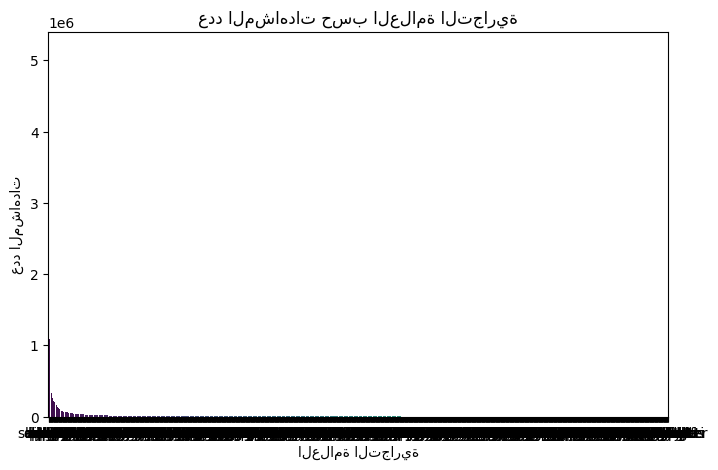

In [ ]:
# حساب عدد المشاهدات لكل علامة تجارية
brand_counts = df['brand'].value_counts(dropna=False)
print("عدد المشاهدات لكل علامة تجارية:")
print(brand_counts)

# رسم عدد المشاهدات لكل علامة تجارية
plt.figure(figsize=(8,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, palette="viridis")
plt.title('عدد المشاهدات حسب العلامة التجارية')
plt.xlabel('العلامة التجارية')
plt.ylabel('عدد المشاهدات')
plt.show()


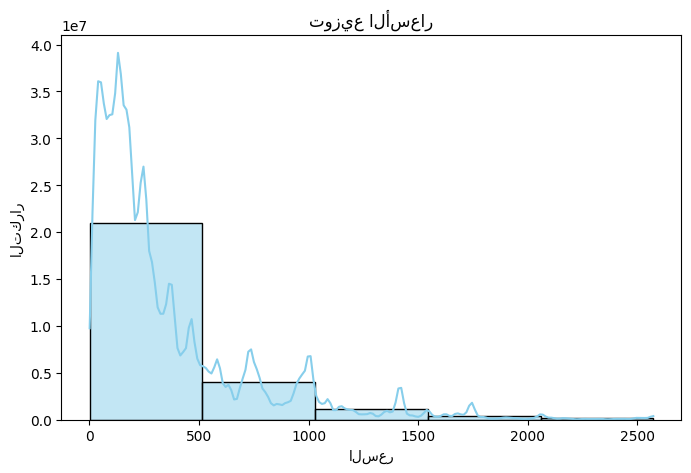

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=5, kde=True, color='skyblue')
plt.title('توزيع الأسعار')
plt.xlabel('السعر')
plt.ylabel('التكرار')
plt.show()



<ipython-input-9-40b55a2dd74e>:3: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_counts = df.resample('S').size()  # إعادة تجميع كل ثانية


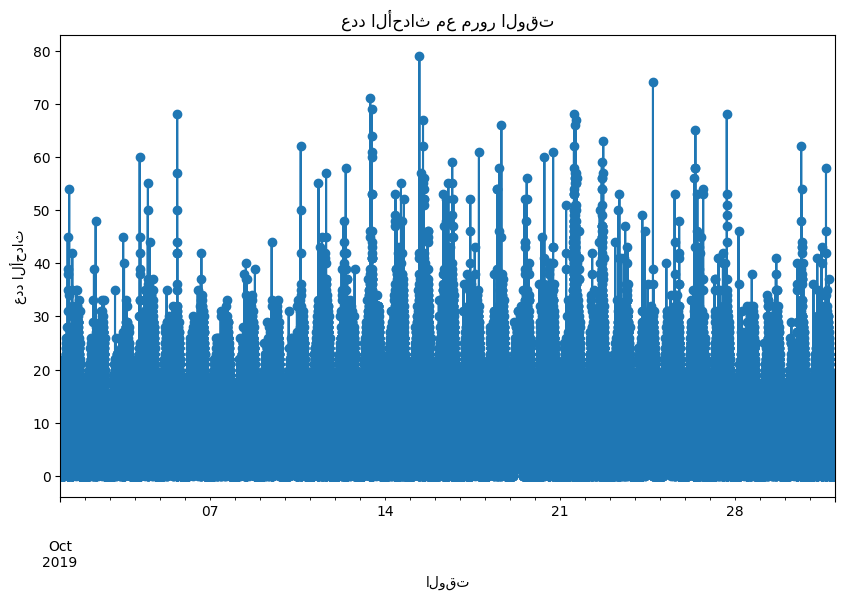

In [ ]:
# يمكننا استخدام resample لحساب عدد الأحداث في فترات زمنية معينة
df.set_index('event_time', inplace=True)
time_counts = df.resample('S').size()  # إعادة تجميع كل ثانية

plt.figure(figsize=(10,6))
time_counts.plot(marker='o')
plt.title('عدد الأحداث مع مرور الوقت')
plt.xlabel('الوقت')
plt.ylabel('عدد الأحداث')
plt.show()


In [ ]:
# إعادة تعيين الفهرس إذا لزم الأمر
df_reset = df.reset_index()

# حفظ البيانات المنظفة
df_reset.to_csv('cleaned_data.csv', index=False)
